In [28]:
import torch
from torch import  nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import torchmetrics
from torchmetrics import Accuracy



In [2]:
train_data = datasets.MNIST(
    root='data',
    train=True,
    transform=ToTensor(),
    target_transform=None,
    download=True
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    transform=ToTensor(),
    download=True
)

In [3]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [4]:
img,label = train_data[0]

Text(0.5, 1.0, '5 - five')

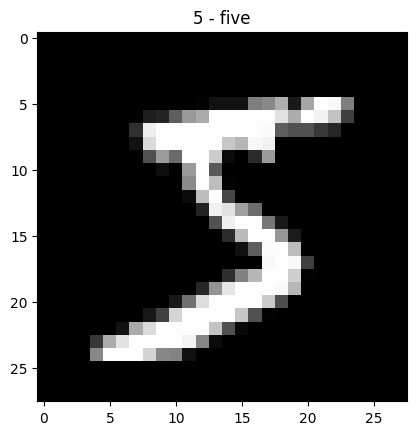

In [5]:
img.shape
plt.imshow(img.squeeze(), cmap = 'gray')
plt.title(class_names[label])

In [6]:
print(img.shape)
img = img.flatten()
print(img.shape)

torch.Size([1, 28, 28])
torch.Size([784])


In [7]:
torch.manual_seed(42)
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(train_data,batch_size=BATCH_SIZE,shuffle=True)
test_loader = DataLoader(test_data,batch_size=BATCH_SIZE,shuffle=False)

In [8]:
class MNIST_v1(nn.Module):
    def __init__(self,input : int , hidden : int , output : int):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input,hidden),
            nn.ReLU(),
            nn.Linear(hidden,output)
        )

    def forward(self,x):
        return self.layer(x)


In [ ]:
class MNIST_v2(nn.Module):
    def __init__(self,input_shape : int , hidden_units : int , output_shape : int,loss_fn :torch.nn.modules.loss ,optimizer : torch.optim , acc_fn : torchmetrics.Accuracy , lr : float = 0.1 ):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
    
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )

        self.loss_fn = loss_fn()
        self.optimizer = optimizer(params = self.parameters(), lr=lr)
        self.acc_fn =acc_fn(task = 'multiclass',num_classes =10)


    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x


In [9]:
model_v1 = MNIST_v1(
    input=784,
    hidden=1568,
     output=10
    )

In [32]:
model_v2 = MNIST_v2(
    input_shape=1,
    hidden_units=120,
    output_shape=10,
    loss_fn = nn.CrossEntropyLoss,
    optimizer=torch.optim.SGD,
    acc_fn=Accuracy,
    lr=0.1
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_v1.parameters(), lr=0.1)
acc_fn = Accuracy(task = 'multiclass',num_classes =10)

In [ ]:
def train_loop( model :torch.nn.Module,
                train_loader : torch.utils.data.DataLoader,
                epochs :int,
                ):
    print(model.__class__.__name__)
    for epoch in range(epochs):
        train_loss = 0

        print(f'epoch {epoch} ---------------------------')
        for batch , (X , y) in enumerate(train_loader):
            model.train()
            y_pred = model(X)
            loss = model.loss_fn(y_pred,y)
            train_loss += loss
            model.optimizer.zero_grad()
            loss.backward()
            model.optimizer.step()
            if batch % 400==0:
                print(f"looked at {(batch+1)*32} samples")
        train_loss = train_loss /len(train_loader)

        print(f"\nTrain loss: {train_loss:.5f}")



def eval_loop(model :torch.nn.Module,
            test_loader : torch.utils.data.DataLoader,
            ):
    test_loss,test_acc = 0,0
    model.acc_fn.reset()
    model.eval()
    with torch.inference_mode():
        for batch,(X,y) in enumerate(test_loader):
            y_pred = model(X)
            pred_label = y_pred.argmax(dim=1)
            loss = model.loss_fn(y_pred,y)
            test_loss +=loss
            test_acc += model.acc_fn(pred_label,y)
        test_loss =test_loss/len(test_loader)
        test_acc = test_acc/len(test_loader)
    print(f"\nTest loss: {test_loss:.5f}, Test acc: {test_acc*100:.2f}%\n")
